# How to use different attribution methods

Eventough we use the HadGEM3-A model provided by the MetOffice to do our analysis, we could also try to do the attribution based on different methods. This could be motivated based on various aspects like not having access to HadGEM3-A, or testing different models for sensitivity analysis. One of these methods is using the available models from the Coupled Model Intercomparison Project (CMIP6) and the methods proposed by Philip et al. (2020) ["A protocol for probabilistic extreme event attribution analyses"](https://ascmo.copernicus.org/articles/6/177/2020/).

In this case we rely on the relation between the mean global temperature and the variable we are interested in (maximum temperature over a day, for example). After that we extrapolate the results to the year we are interested in to represent ALL as well as the year that represents the conterfactual world (NAT).

We start the analysis similarly to the other case by preprocessing the observation and model datasets:

In [22]:
import xarray as xr
import xclim

import cartopy.crs as ccrs
import climattr as eea
import matplotlib.pyplot as plt
import scipy.stats

In [23]:
# define variables
mask_name = '/home/rafael/Downloads/amazonas.shp'
obs_dataset_path = '/media/rafael/Rafael/cmip6/jasmin/era5/amazon/era5_dataset.1981.2023.daily.t2m.nc'
all_dataset_path = '/media/rafael/Rafael/cmip6/jasmin/amazon/tasmax_day_IPSL-CM6A-LR_historical_*.nc'

In [24]:
obs_dataset = xr.open_mfdataset(obs_dataset_path)

# filter time and area
obs_dataset = eea.filter.filter_time(obs_dataset, months=[12, 1, 2])
obs_dataset = eea.filter.filter_area(obs_dataset[['t2m']], mask=mask_name, plot_area=False)

# calculate the area mean
obs_dataset_mean = obs_dataset.mean(dim=['longitude', 'latitude'], keep_attrs=True)

# calculate maximum one day temperature
obs_dataset_indice = eea.indice.xclim_indice(obs_dataset_mean, 'tx_max', tasmax='t2m', freq= 'YE-NOV')

# load data into memory
obs_dataset_indice = obs_dataset_indice.load()

In [25]:
# ALL
all_dataset = eea.utils.multiens_netcdf(all_dataset_path, chunks={'time': 100})

all_dataset = eea.filter.filter_time(all_dataset, itime='1850-01-01', etime='2014-02-28', months=[12, 1, 2])
all_dataset = eea.filter.filter_area(all_dataset[['tasmax']], mask=mask_name, plot_area=False)

all_dataset_mean = all_dataset.mean(dim=['lon', 'lat'], keep_attrs=True)
all_dataset_indice = eea.indice.xclim_indice(all_dataset_mean[['tasmax']], 'tx_max', tasmax='tasmax', freq='YE-NOV')

# load data into memory
all_dataset_indice = all_dataset_indice.load()

# scale the dataset and then plot the data again
all_dataset_indice_scaled = eea.correction.scaling(all_dataset_indice, all_dataset_indice, '1981-01-01', '2010-12-31', method='add')

We can load the global average temperature from the model we are using and scenario (for dates after 2015) to see how the relation is between it and our indice. The global temperature is smoothed using a 4 year running mean

Text(0, 0.5, 'tx_max')

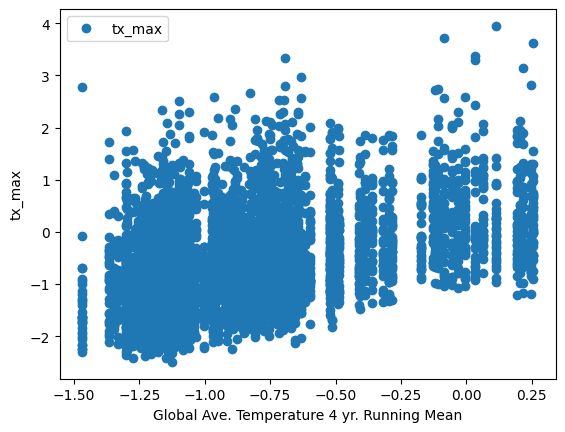

In [5]:
# get global temperature
global_tas = eea.utils.get_global_temperature_anomaly('IPSL-CM6A-LR', scenario='ssp585')
global_tas = global_tas.sort_index()

# 4-yr running mean
global_tas['tas'] = global_tas['tas'].rolling(4, center=True).mean()
dataframe = all_dataset_indice_scaled.to_dataframe().reset_index().set_index('time').join(global_tas).dropna()

fig, ax = plt.subplots()

dataframe.plot(x='tas', y='tx_max', ax=ax, ls='', marker='o')
     
ax.set_xlabel('Global Ave. Temperature 4 yr. Running Mean')
ax.set_ylabel('tx_max')

We need to choose how the expected value and the variance ($\mu$ and $\sigma$, respectively) vary with respect to the global average temperature ($T'$). The first method is supposing a linear relation of the form $\mu = \mu_0 + \alpha T' $ and that $\sigma = \sigma_0$, which means that $\sigma$ does not change with $T'$. This is usually used for temperature events, according to the article. For precipitation events, however we might assume that $\mu$ scales exponentially and that the variance is not constant, so therefore they propose to use:

$$\mu = \mu_0 \exp(\alpha * T' / \mu_0)$$ 
$$\sigma = \sigma_0 \exp(\alpha * T' / \mu_0)$$

In the case of distributions that also have a shape parameter $\xi$ like the GEV in both cases they are assumed constant. Therefore we use Maximum Likelihood Estimation (MLE) to obtain $\mu_0$, $\sigma_0$, $\alpha$, and $\xi$ of the fitted distribution. 

In this case we are using the GEV fit with the linear approach to estimate the data from the event we want to analyze (ALL; 2003) and for the contertactual world (NAT, 1900).

In [14]:
# get global temperature
global_tas = eea.utils.get_global_temperature_anomaly('IPSL-CM6A-LR', scenario='ssp585')
global_tas = global_tas.sort_index()

params, all_wwa, nat_wwa = eea.attribution.fit_wwa_data(all_dataset_indice_scaled, global_tas, 'genextreme', all_date='2003-11-30', strategy='linear')

Optimization terminated successfully.
         Current function value: 1.144423
         Iterations: 195
         Function evaluations: 333
                               GEVModel Results                               
Dep. Variable:                 tx_max   Log-Likelihood:                -6042.6
Model:                       GEVModel   AIC:                         1.209e+04
Method:            Maximum Likelihood   BIC:                         1.211e+04
Date:                Mon, 14 Oct 2024                                         
Time:                        07:13:39                                         
No. Observations:                5280                                         
Df Residuals:                    5279                                         
Df Model:                           0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

/home/rafael/miniconda3/envs/impact-env/lib/python3.10/site-packages/statsmodels/base/model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
/home/rafael/miniconda3/envs/impact-env/lib/python3.10/site-packages/statsmodels/base/model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")


We can check the result by calculating $\mu$ and $\sigma$ from the estimated parameters: 

Text(0, 0.5, 'tx_max')

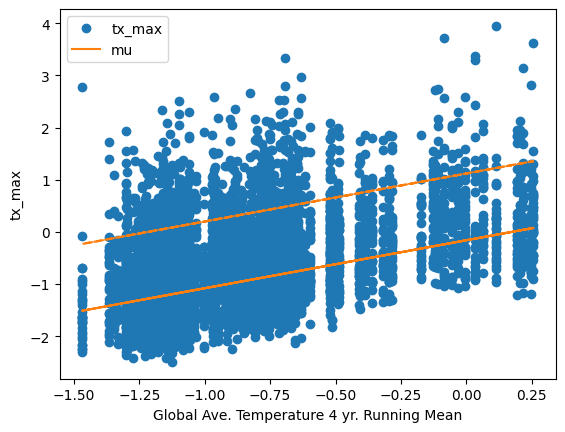

In [19]:
dataframe['mu'], dataframe['sigma'] = eea.minimization.utils.linear_function(params[0], params[1], params[3], dataframe['tas'])
dataframe = dataframe.sort_index()

fig, ax = plt.subplots()

dataframe.plot(x='tas', y='tx_max', ax=ax, ls='', marker='o')
dataframe.plot(x='tas', y='mu', ax=ax, color='C1')
ax.plot(dataframe['tas'], dataframe['mu'] + 1.96 * dataframe['sigma'], color='C1', ls='--')

ax.set_xlabel('Global Ave. Temperature 4 yr. Running Mean')
ax.set_ylabel('tx_max')


After that we can proceed like usually to estimate the risk ratio and plot the the results:

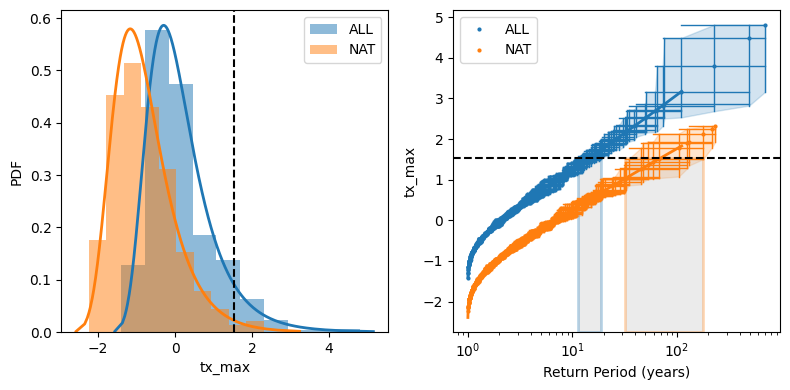

In [20]:
# plot histogram and RP plot to compare ALL and NAT
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8,4))

eea.attribution.histogram_plot(ax1, all_wwa, nat_wwa, scipy.stats.genextreme, 1.545)
eea.attribution.rp_plot(ax2, all_wwa, nat_wwa, scipy.stats.genextreme, 1.545)

ax1.set_xlabel('tx_max')
ax1.set_ylabel('PDF')
ax2.set_xlabel('Return Period (years)')
ax2.set_ylabel('tx_max')

plt.tight_layout()

In [21]:
eea.attribution.attribution_metrics(all_wwa, nat_wwa, scipy.stats.norm, 1.545)

,value,ci_inf,ci_sup
PR,28.411099,11.391700,86.542678
FAR,0.964802,0.912217,0.988445
RP_ALL,18.434721,12.386053,31.121103
RP_NAT,540.695205,245.612365,1507.397678
